# Library and Data

## Import Library and Dataset

In [15]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

ImportError: cannot import name 'rgb2gray' from 'skimage' (c:\Users\FatCat\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\__init__.py)

In [5]:
dataset = load_dataset("amaye15/stanford-dogs")

## Exploratory Data Analysis

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'pixel_values'],
        num_rows: 14406
    })
    test: Dataset({
        features: ['label', 'pixel_values'],
        num_rows: 6174
    })
})

In [7]:
train_set = dataset['train']
test_set = dataset['test']

In [8]:
print("Train set shape: ", train_set.shape)
print("Test set shape: ", test_set.shape)

Train set shape:  (14406, 2)
Test set shape:  (6174, 2)


In [9]:
train_set.features['label'].names

['Affenpinscher',
 'Afghan Hound',
 'African Hunting Dog',
 'Airedale',
 'American Staffordshire Terrier',
 'Appenzeller',
 'Australian Terrier',
 'Basenji',
 'Basset',
 'Beagle',
 'Bedlington Terrier',
 'Bernese Mountain Dog',
 'Black And Tan Coonhound',
 'Blenheim Spaniel',
 'Bloodhound',
 'Bluetick',
 'Border Collie',
 'Border Terrier',
 'Borzoi',
 'Boston Bull',
 'Bouvier Des Flandres',
 'Boxer',
 'Brabancon Griffon',
 'Briard',
 'Brittany Spaniel',
 'Bull Mastiff',
 'Cairn',
 'Cardigan',
 'Chesapeake Bay Retriever',
 'Chihuahua',
 'Chow',
 'Clumber',
 'Cocker Spaniel',
 'Collie',
 'Curly Coated Retriever',
 'Dandie Dinmont',
 'Dhole',
 'Dingo',
 'Doberman',
 'English Foxhound',
 'English Setter',
 'English Springer',
 'Entlebucher',
 'Eskimo Dog',
 'Flat Coated Retriever',
 'French Bulldog',
 'German Shepherd',
 'German Short Haired Pointer',
 'Giant Schnauzer',
 'Golden Retriever',
 'Gordon Setter',
 'Great Dane',
 'Great Pyrenees',
 'Greater Swiss Mountain Dog',
 'Groenendael',


In [10]:
train_set['pixel_values'][:5]

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=350x270>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x336>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=373x245>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=365x500>]

In [16]:
def vis_sample(dataset, n_sample):
    fig, axs = plt.subplots(1, 5, figsize=(12,8))
    axs = axs.ravel()
    for i, img in enumerate(dataset['pixel_values'][:n_sample]):
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(f"Image {i+1}")
        
    plt.tight_layout()
    plt.show()

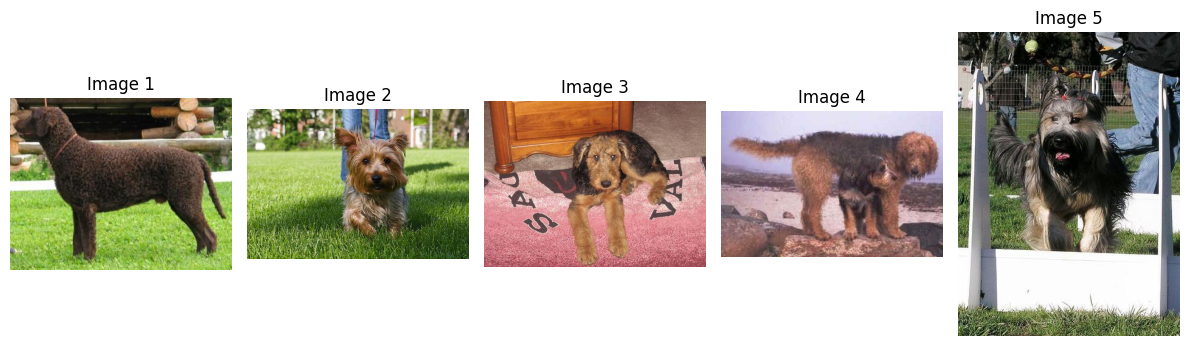

In [18]:
vis_sample(train_set, 5)

# Preprocessing

- Resize
- Grayscale
- Flatten
- Normalize
- Mean Normalization

In [ ]:
def preprocess(dataset):
    X, y = [], []
    
    for item in dataset:
        img = Image.open(item['pixel_value'])

        img = img.resize((224, 224), Image.Resampling.LANCZOS)
        vis_sample(dataset, 1)

# Convert to grayscale
        img = img.convert('L')
        vis_sample(dataset, 1)

        img_flat = np.array(img).flatten().astype(np.float32)

        img_flat /= 255.0
        
        img_flat -= np.mean(img_flat)

        X.append(img_flat)
        y.append(item['label'])

    return np.array(X), np.array(y)
    

In [21]:
train_set = preprocess(train_set)

KeyError: 'pixel_value'